# Bible Embeddings: Ephesians

This notebook indexes and visualizes the book of Ephesians from the Cornilescu Bible using OpenAI's `text-embedding-3-small` model.

In [23]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

DATA_DIR = Path('../data')

## Load and Filter Data

In [24]:
# Load Bible data
with open('../data/cornilescu_vdcc.json', 'r', encoding='utf-8') as f:
    bible_data = json.load(f)

# Filter to Ephesians only
ephesians_verses = [v for v in bible_data['verses'] if v['book'] == 'ephesians']

print(f"Total verses in Ephesians: {len(ephesians_verses)}")
print(f"\nFirst verse: {ephesians_verses[0]}")

Total verses in Ephesians: 155

First verse: {'book': 'ephesians', 'chapter': 1, 'verse': 1, 'text': 'Pavel, apostol al lui Isus Hristos, prin voia lui Dumnezeu, către sfinţii care sunt în Efes şi credincioşii în Hristos Isus:'}


In [25]:
# Create a DataFrame for easier manipulation
df = pd.DataFrame(ephesians_verses)
df['reference'] = df.apply(lambda x: f"Efeseni {x['chapter']}:{x['verse']}", axis=1)
df.head(10)

,book,chapter,verse,text,reference
0,ephesians,1,1,"Pavel, apostol al lui Isus Hristos, prin voia ...",Efeseni 1:1
1,ephesians,1,2,"Har şi pace de la Dumnezeu, Tatăl nostru, şi d...",Efeseni 1:2
2,ephesians,1,3,"Binecuvântat să fie Dumnezeu, Tatăl Domnului n...",Efeseni 1:3
3,ephesians,1,4,"În El, Dumnezeu ne-a ales înainte de întemeier...",Efeseni 1:4
4,ephesians,1,5,ne-a rânduit mai dinainte să fim înfiaţi prin ...,Efeseni 1:5
5,ephesians,1,6,spre lauda slavei harului Său pe care ni l-a d...,Efeseni 1:6
6,ephesians,1,7,"În El avem răscumpărarea, prin sângele Lui, ie...",Efeseni 1:7
7,ephesians,1,8,"pe care l-a răspândit din belşug peste noi, pr...",Efeseni 1:8
8,ephesians,1,9,căci a binevoit să ne descopere taina voii Sal...,Efeseni 1:9
9,ephesians,1,10,ca să-l aducă la îndeplinire la împlinirea vre...,Efeseni 1:10


## Verse Windowing Strategies

Different strategies for grouping verses to provide context when generating embeddings.

In [49]:
from typing import Callable

# Type alias for windowing functions
WindowingFn = Callable[[list[str], int], str]


def trailing_window(texts: list[str], idx: int, window_size: int = 3) -> str:
    """
    Use current verse + previous verses as context.
    For early verses, pad with following verses to maintain window size.
    
    Example (window_size=3):
      - idx=0: texts[0:2] (verses 1-2, special case)
      - idx=1: texts[0:3] (verses 1-3)
      - idx=2: texts[0:3] (verses 1-3) 
      - idx=3: texts[1:4] (verses 2-4)
      - idx=N: texts[N-2:N+1] (3 verses ending at N)
    """
    if idx < window_size - 1:
        # Not enough previous verses, use from start
        start = 0
        end = min(window_size, len(texts))
    else:
        start = idx - (window_size - 1)
        end = idx + 1
    return ' '.join(texts[start:end])


def centered_window(texts: list[str], idx: int, window_size: int = 3) -> str:
    """
    Use verses centered around the current verse.
    Adjusts at boundaries to maintain window size when possible.
    
    Example (window_size=3):
      - idx=0: texts[0:2] (verses 1-2)
      - idx=1: texts[0:3] (verses 1-3)
      - idx=N: texts[N-1:N+2] (verse before, current, verse after)
    """
    half = window_size // 2
    start = max(0, idx - half)
    end = min(len(texts), idx + half + 1)
    
    # Adjust if we hit a boundary
    if start == 0:
        end = min(len(texts), window_size)
    elif end == len(texts):
        start = max(0, len(texts) - window_size)
    
    return ' '.join(texts[start:end])


def leading_window(texts: list[str], idx: int, window_size: int = 3) -> str:
    """
    Use current verse + following verses as context.
    For late verses, pad with previous verses to maintain window size.
    
    Example (window_size=3):
      - idx=0: texts[0:3] (verses 1-3)
      - idx=N-2: texts[N-3:N] (last 3 verses)
    """
    if idx + window_size > len(texts):
        # Not enough following verses, adjust start
        end = len(texts)
        start = max(0, len(texts) - window_size)
    else:
        start = idx
        end = idx + window_size
    return ' '.join(texts[start:end])


def single_verse(texts: list[str], idx: int, window_size: int = 1) -> str:
    """No windowing - just the single verse."""
    return texts[idx]


# Available windowing strategies
WINDOWING_STRATEGIES = {
    'trailing': trailing_window,
    'centered': centered_window,
    'leading': leading_window,
    'single': single_verse,
}

# Current strategy to use
WINDOW_SIZE = 3
WINDOWING_STRATEGY = 'centered'

In [50]:
# Preview windowing for first few verses
texts = df['text'].tolist()
print(f"Using '{WINDOWING_STRATEGY}' strategy with window_size={WINDOW_SIZE}\n")

windowing_fn = WINDOWING_STRATEGIES[WINDOWING_STRATEGY]
for i in range(min(5, len(texts))):
    windowed = windowing_fn(texts, i, WINDOW_SIZE)
    print(f"Verse {i+1} ({df.iloc[i]['reference']}):")
    print(f"  Original: {texts[i][:60]}...")
    print(f"  Windowed: {windowed[:80]}...")
    print()

Using 'centered' strategy with window_size=3

Verse 1 (Efeseni 1:1):
  Original: Pavel, apostol al lui Isus Hristos, prin voia lui Dumnezeu, ...
  Windowed: Pavel, apostol al lui Isus Hristos, prin voia lui Dumnezeu, către sfinţii care s...

Verse 2 (Efeseni 1:2):
  Original: Har şi pace de la Dumnezeu, Tatăl nostru, şi de la Domnul Is...
  Windowed: Pavel, apostol al lui Isus Hristos, prin voia lui Dumnezeu, către sfinţii care s...

Verse 3 (Efeseni 1:3):
  Original: Binecuvântat să fie Dumnezeu, Tatăl Domnului nostru Isus Hri...
  Windowed: Har şi pace de la Dumnezeu, Tatăl nostru, şi de la Domnul Isus Hristos. Binecuvâ...

Verse 4 (Efeseni 1:4):
  Original: În El, Dumnezeu ne-a ales înainte de întemeierea lumii, ca s...
  Windowed: Binecuvântat să fie Dumnezeu, Tatăl Domnului nostru Isus Hristos, care ne-a bine...

Verse 5 (Efeseni 1:5):
  Original: ne-a rânduit mai dinainte să fim înfiaţi prin Isus Hristos, ...
  Windowed: În El, Dumnezeu ne-a ales înainte de întemeierea lumii, ca 

## Load or Generate Embeddings

Check if embeddings are cached locally. If not, generate them via OpenAI API and save for future use.

In [51]:
def get_embeddings(texts: list[str], model: str = "text-embedding-3-small") -> list[list[float]]:
    """Get embeddings for a list of texts using OpenAI API."""
    client = OpenAI()
    response = client.embeddings.create(
        input=texts,
        model=model
    )
    return [item.embedding for item in response.data]


def get_cache_filename(strategy: str, window_size: int) -> Path:
    """Generate cache filename based on windowing strategy."""
    if strategy == 'single':
        return DATA_DIR / 'ephesians_embeddings_single.json'
    return DATA_DIR / f'ephesians_embeddings_{strategy}_w{window_size}.json'


def load_or_generate_embeddings(
    df: pd.DataFrame, 
    strategy: str = 'trailing',
    window_size: int = 3
) -> pd.DataFrame:
    """Load embeddings from cache or generate them with windowing."""
    cache_file = get_cache_filename(strategy, window_size)
    windowing_fn = WINDOWING_STRATEGIES[strategy]
    
    if cache_file.exists():
        print(f"Loading cached embeddings from {cache_file}")
        cached_df = pd.read_json(cache_file)
        df['embedding'] = cached_df['embedding'].tolist()
        df['windowed_text'] = cached_df['windowed_text'].tolist()
        print(f"Loaded {len(df)} embeddings from cache")
    else:
        print(f"Generating embeddings via OpenAI API...")
        print(f"Strategy: {strategy}, Window size: {window_size}")
        
        # Apply windowing to create context-rich text for embedding
        texts = df['text'].tolist()
        windowed_texts = [windowing_fn(texts, i, window_size) for i in range(len(texts))]
        df['windowed_text'] = windowed_texts
        
        # Generate embeddings for windowed texts
        embeddings = get_embeddings(windowed_texts)
        df['embedding'] = embeddings
        print(f"Generated {len(embeddings)} embeddings (dimension: {len(embeddings[0])})")
        
        # Save to cache
        output_df = df[['book', 'chapter', 'verse', 'text', 'reference', 'windowed_text', 'embedding']].copy()
        cache_file.parent.mkdir(parents=True, exist_ok=True)
        output_df.to_json(cache_file, orient='records', force_ascii=False, indent=2)
        print(f"Saved embeddings to {cache_file}")
    
    return df

In [52]:
df = load_or_generate_embeddings(df, strategy=WINDOWING_STRATEGY, window_size=WINDOW_SIZE)

Loading cached embeddings from ../data/ephesians_embeddings_centered_w3.json
Loaded 155 embeddings from cache


## Visualize Embeddings with t-SNE

In [53]:
# Convert embeddings to numpy array
embedding_matrix = np.array(df['embedding'].tolist())

# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, perplexity=15, random_state=42, max_iter=1000)
embedding_2d = tsne.fit_transform(embedding_matrix)

df['x'] = embedding_2d[:, 0]
df['y'] = embedding_2d[:, 1]

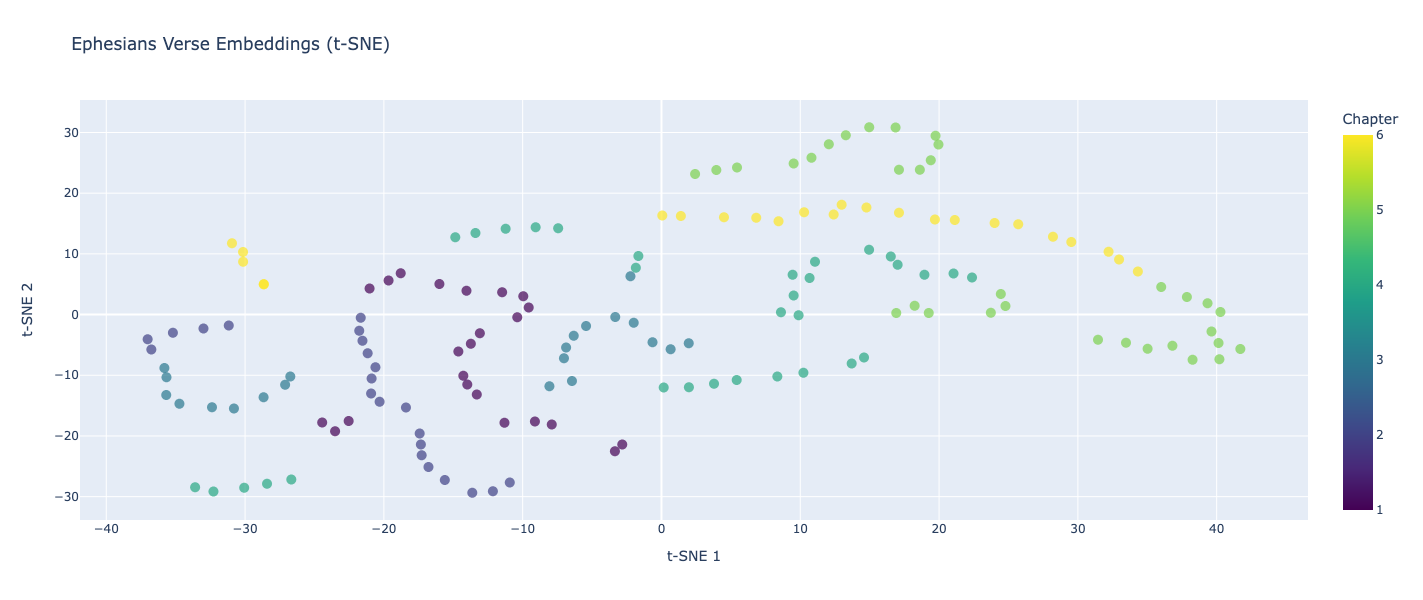

In [54]:
import plotly.express as px

# Interactive t-SNE plot
fig = px.scatter(
    df,
    x='x',
    y='y',
    color='chapter',
    hover_data=['reference', 'text'],
    title='Ephesians Verse Embeddings (t-SNE)',
    labels={'x': 't-SNE 1', 'y': 't-SNE 2', 'chapter': 'Chapter'},
    color_continuous_scale='Viridis'
)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.update_layout(width=900, height=600)
fig.show()

## Visualize Embeddings with PCA

In [55]:
# Reduce dimensions with PCA
pca = PCA(n_components=2, random_state=42)
embedding_pca = pca.fit_transform(embedding_matrix)

df['pca_x'] = embedding_pca[:, 0]
df['pca_y'] = embedding_pca[:, 1]

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

PCA explained variance ratio: [0.08010007 0.05784711]
Total variance explained: 13.79%


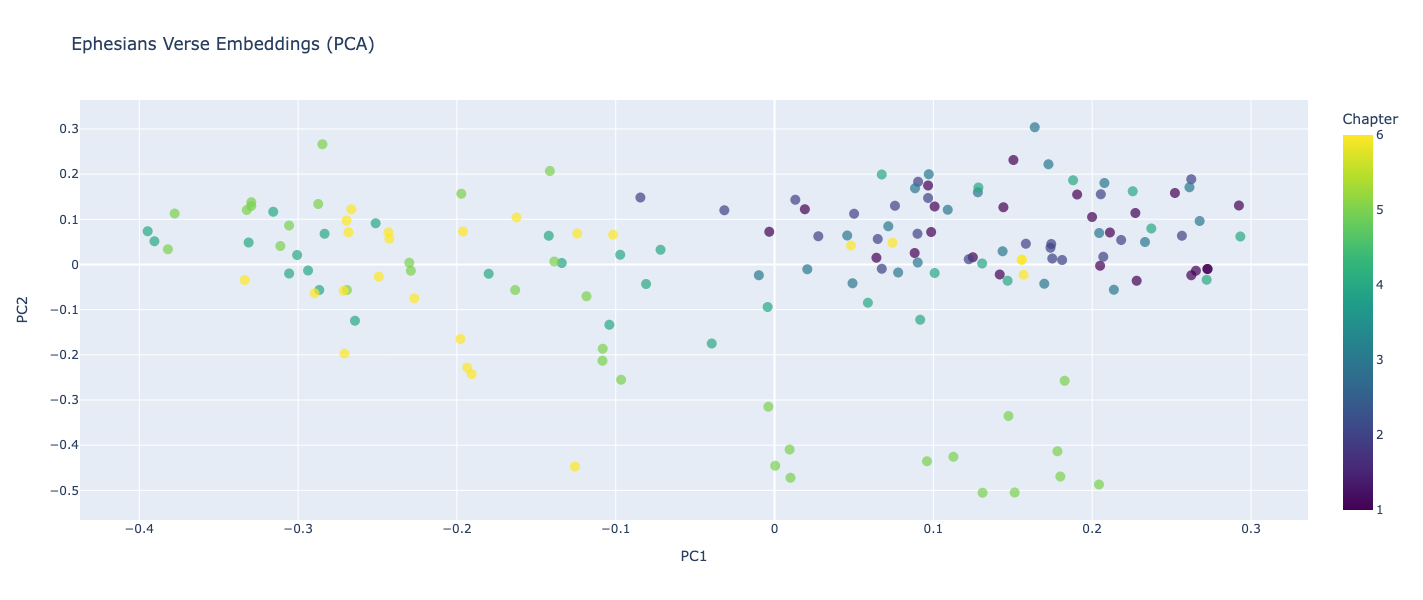

In [56]:
# Interactive PCA plot
fig = px.scatter(
    df,
    x='pca_x',
    y='pca_y',
    color='chapter',
    hover_data=['reference', 'text'],
    title='Ephesians Verse Embeddings (PCA)',
    labels={'pca_x': 'PC1', 'pca_y': 'PC2', 'chapter': 'Chapter'},
    color_continuous_scale='Viridis'
)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.update_layout(width=900, height=600)
fig.show()

## Clustering Analysis

Use K-Means and other clustering algorithms to find thematic groupings in the verses.

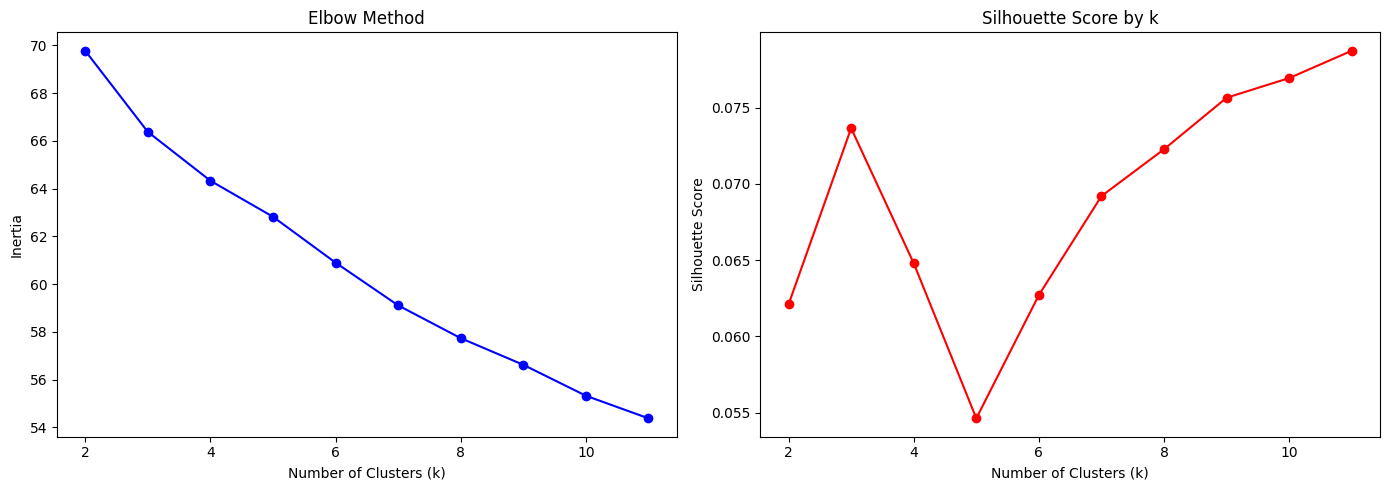

Best silhouette score: 0.079 at k=11


In [58]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Find optimal number of clusters using elbow method and silhouette score
k_range = range(2, 12)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(embedding_matrix)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(embedding_matrix, kmeans.labels_))

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

print(f"Best silhouette score: {max(silhouette_scores):.3f} at k={k_range[silhouette_scores.index(max(silhouette_scores))]}")

In [59]:
# Apply K-Means with chosen number of clusters
N_CLUSTERS = 11  # Adjust based on elbow/silhouette analysis

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(embedding_matrix)

print(f"Cluster distribution:")
print(df['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0     10
1     25
2     24
3      6
4     27
5      8
6     12
7      9
8      8
9      8
10    18
Name: count, dtype: int64


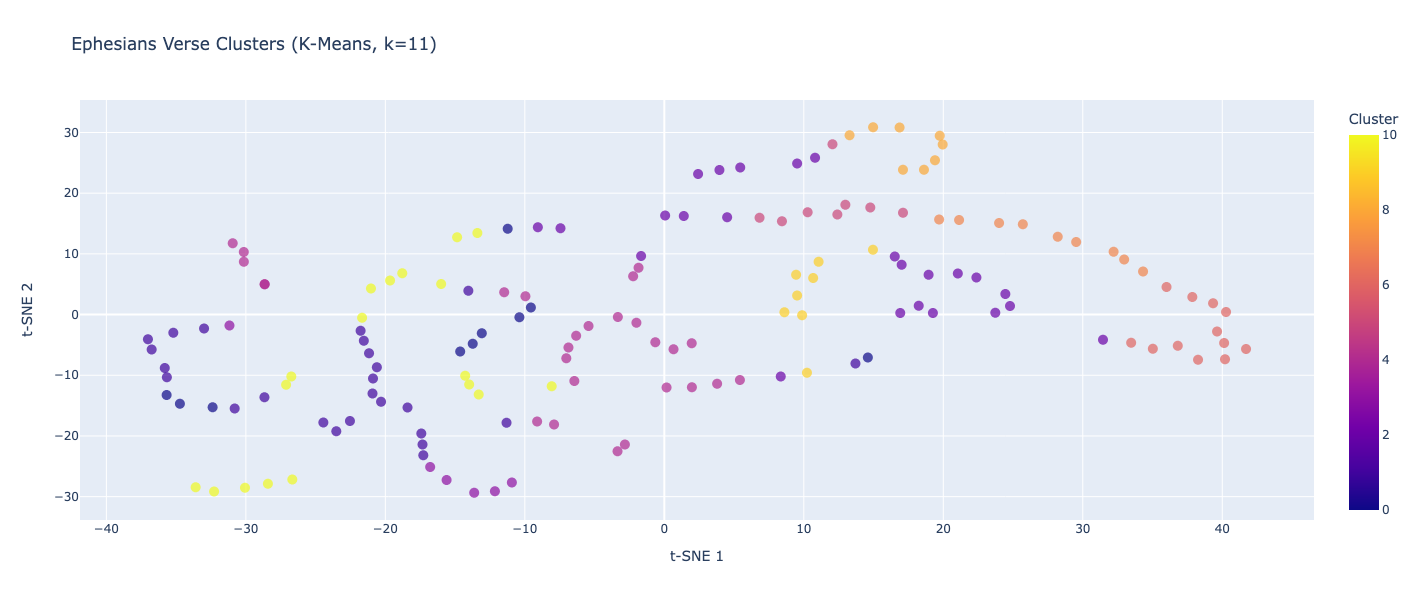

In [60]:
# Visualize clusters on t-SNE
fig = px.scatter(
    df,
    x='x',
    y='y',
    color='cluster',
    hover_data=['reference', 'text', 'chapter'],
    title=f'Ephesians Verse Clusters (K-Means, k={N_CLUSTERS})',
    labels={'x': 't-SNE 1', 'y': 't-SNE 2', 'cluster': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.update_layout(width=900, height=600)
fig.show()

In [61]:
# Show sample verses from each cluster
for cluster_id in sorted(df['cluster'].unique()):
    cluster_verses = df[df['cluster'] == cluster_id]
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id} ({len(cluster_verses)} verses)")
    print(f"Chapters: {sorted(cluster_verses['chapter'].unique())}")
    print(f"{'='*60}")
    
    # Show 3 sample verses from each cluster
    for _, row in cluster_verses.head(3).iterrows():
        print(f"\n{row['reference']}:")
        print(f"  {row['text'][:120]}...")


CLUSTER 0 (10 verses)
Chapters: [np.int64(1), np.int64(3), np.int64(4)]

Efeseni 1:12:
  ca să slujim de laudă slavei Sale, noi, care mai dinainte am nădăjduit în Hristos....

Efeseni 1:13:
  Şi voi, după ce aţi auzit Cuvântul adevărului (Evanghelia mântuirii voastre), aţi crezut în El şi aţi fost pecetluiţi cu...

Efeseni 1:14:
  şi care este o arvună a moştenirii noastre, pentru răscumpărarea celor câştigaţi de Dumnezeu, spre lauda slavei Lui....

CLUSTER 1 (25 verses)
Chapters: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Efeseni 1:5:
  ne-a rânduit mai dinainte să fim înfiaţi prin Isus Hristos, după buna plăcere a voii Sale,...

Efeseni 1:6:
  spre lauda slavei harului Său pe care ni l-a dat în Preaiubitul Lui....

Efeseni 1:7:
  În El avem răscumpărarea, prin sângele Lui, iertarea păcatelor, după bogăţiile harului Său...

CLUSTER 2 (24 verses)
Chapters: [np.int64(4), np.int64(5), np.int64(6)]

Efeseni 4:2:
  cu toată smerenia şi blândeţea, cu îndelungă răbdare; îngăduiţi

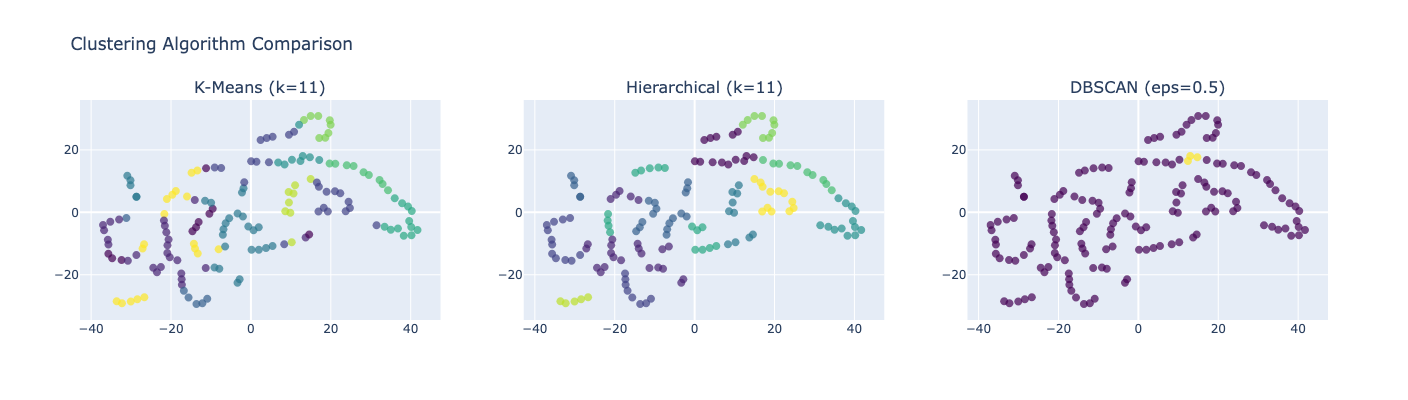

DBSCAN found 2 clusters (including noise as -1)


In [62]:
# Compare clustering algorithms
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=N_CLUSTERS)
df['hierarchical_cluster'] = hierarchical.fit_predict(embedding_matrix)

# DBSCAN (density-based)
dbscan = DBSCAN(eps=0.5, min_samples=3)
df['dbscan_cluster'] = dbscan.fit_predict(embedding_matrix)

# Compare all three
fig = make_subplots(rows=1, cols=3, subplot_titles=[
    f'K-Means (k={N_CLUSTERS})',
    f'Hierarchical (k={N_CLUSTERS})', 
    f'DBSCAN (eps=0.5)'
])

for i, (col, title) in enumerate([
    ('cluster', 'K-Means'),
    ('hierarchical_cluster', 'Hierarchical'),
    ('dbscan_cluster', 'DBSCAN')
], 1):
    fig.add_trace(
        go.Scatter(
            x=df['x'], y=df['y'],
            mode='markers',
            marker=dict(color=df[col], colorscale='viridis', size=8, opacity=0.7),
            text=df['reference'],
            hovertemplate='%{text}<extra></extra>'
        ),
        row=1, col=i
    )

fig.update_layout(height=400, width=1200, title_text="Clustering Algorithm Comparison", showlegend=False)
fig.show()

print(f"DBSCAN found {len(df['dbscan_cluster'].unique())} clusters (including noise as -1)")

## Semantic Search Demo

In [63]:
def semantic_search(query: str, df: pd.DataFrame, top_k: int = 5) -> pd.DataFrame:
    """Search for verses semantically similar to the query."""
    query_embedding = get_embeddings([query])[0]
    
    def cosine_similarity(a, b):
        return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    
    df = df.copy()
    df['similarity'] = df['embedding'].apply(lambda x: cosine_similarity(query_embedding, x))
    return df.nlargest(top_k, 'similarity')[['reference', 'text', 'similarity']]

In [64]:
# Example searches
results = semantic_search("armura lui Dumnezeu", df)
print("Search: 'armura lui Dumnezeu'\n")
for _, row in results.iterrows():
    print(f"{row['reference']} (similarity: {row['similarity']:.3f})")
    print(f"  {row['text'][:100]}...\n")

Search: 'armura lui Dumnezeu'

Efeseni 6:12 (similarity: 0.615)
  Căci noi n-avem de luptat împotriva cărnii şi sângelui, ci împotriva căpeteniilor, împotriva domniil...

Efeseni 6:14 (similarity: 0.606)
  Staţi gata, dar, având mijlocul încins cu adevărul, îmbrăcaţi cu platoşa neprihănirii,...

Efeseni 6:13 (similarity: 0.593)
  De aceea, luaţi toată armura lui Dumnezeu, ca să vă puteţi împotrivi în ziua cea rea şi să rămâneţi ...

Efeseni 6:11 (similarity: 0.550)
  Îmbrăcaţi-vă cu toată armura lui Dumnezeu, ca să puteţi ţine piept împotriva uneltirilor diavolului....

Efeseni 4:7 (similarity: 0.529)
  Dar fiecăruia din noi harul i-a fost dat după măsura darului lui Hristos....



In [65]:
# Another example search
results = semantic_search("dragoste și unitate", df)
print("Search: 'dragoste și unitate'\n")
for _, row in results.iterrows():
    print(f"{row['reference']} (similarity: {row['similarity']:.3f})")
    print(f"  {row['text'][:100]}...\n")

Search: 'dragoste și unitate'

Efeseni 4:3 (similarity: 0.590)
  şi căutaţi să păstraţi unirea Duhului, prin legătura păcii....

Efeseni 5:3 (similarity: 0.499)
  Curvia sau orice alt fel de necurăţie, sau lăcomia de avere nici să nu fie pomenite între voi, aşa c...

Efeseni 4:4 (similarity: 0.487)
  Este un singur trup, un singur Duh, după cum şi voi aţi fost chemaţi la o singură nădejde a chemării...

Efeseni 4:16 (similarity: 0.472)
  Din El tot trupul, bine închegat şi strâns legat, prin ceea ce dă fiecare încheietură, îşi primeşte ...

Efeseni 6:1 (similarity: 0.465)
  Copii, ascultaţi în Domnul de părinţii voştri, căci este drept....

